In [1]:
import os
from pathlib import Path

def encontrar_raiz_repo(marcador=".git"):
    caminho = Path.cwd()
    for pasta in [caminho, *caminho.parents]:
        if (pasta / marcador).exists():
            return pasta
    raise FileNotFoundError(f"Não achei {marcador} subindo a partir de {caminho}")

RAIZ = encontrar_raiz_repo()
print(RAIZ)

/usr/src/myapp


In [2]:
import pandas as pd
import numpy
from sklearn.model_selection import train_test_split

## Importando dados

In [3]:
features = pd.read_csv(RAIZ / "data/processed/features.csv", index_col=0)
metadata_cols = pd.read_csv(RAIZ / "data/processed/metadata_filtrada.csv").set_index("sample")[["Species", "source_type", "WHO_Priority"]]

In [4]:
features.shape

(2210, 9)

In [5]:
features.isna().sum()

n_class_A_carbapenemase_plasmidial    0
prop_carbapenemase_BD_plasmidial      0
n_esbl_plasmidial                     0
n_genes_efflux_plasmidial             0
pct_contigs_plasmidial                0
n_plasmids_com_conjugacao             0
gc_diff_plasmid_cromossomo            0
Species                               0
WHO_Priority                          0
dtype: int64

In [6]:
features.head()

,n_class_A_carbapenemase_plasmidial,prop_carbapenemase_BD_plasmidial,n_esbl_plasmidial,n_genes_efflux_plasmidial,pct_contigs_plasmidial,n_plasmids_com_conjugacao,gc_diff_plasmid_cromossomo,Species,WHO_Priority
sample,,,,,,,,,
GCA_000316425.1,0,0,0,2,5.675676,5,-2.92,Escherichia coli,Critical
GCA_000355215.1,0,0,0,10,42.857143,11,-2.10,Escherichia coli,Critical
GCA_000355195.1,0,0,0,3,44.230769,8,-1.50,Escherichia coli,Critical
GCA_000355235.1,0,0,1,2,9.677419,2,-1.13,Escherichia coli,Critical
GCA_000355255.1,0,0,1,2,33.333333,10,-1.17,Escherichia coli,Critical


In [9]:
features = features.drop(['Species', 'WHO_Priority'], axis=1)

## Fazendo o split

In [ ]:
df_train, df_temp = train_test_split(
    features, 
    test_size=0.3, 
    random_state=42,
)

df_valid, df_test = train_test_split(
    df_temp, 
    test_size=0.66, 
    random_state=42,
)

In [11]:
pct_train = round((df_train.shape[0] / features.shape[0]), 2)
pct_valid = round((df_valid.shape[0] / features.shape[0]), 2)
pct_test = round((df_test.shape[0] / features.shape[0]), 2)

print("-" * 10)
print(f"df_train: {df_train.shape}, - {pct_train}")
print(f"df_valid: {df_valid.shape} - {pct_valid}")
print(f"df_test: {df_test.shape} - {pct_test}")

----------
df_train: (1547, 7), - 0.7
df_valid: (225, 7) - 0.1
df_test: (438, 7) - 0.2


## Vendo a proporção dos dados

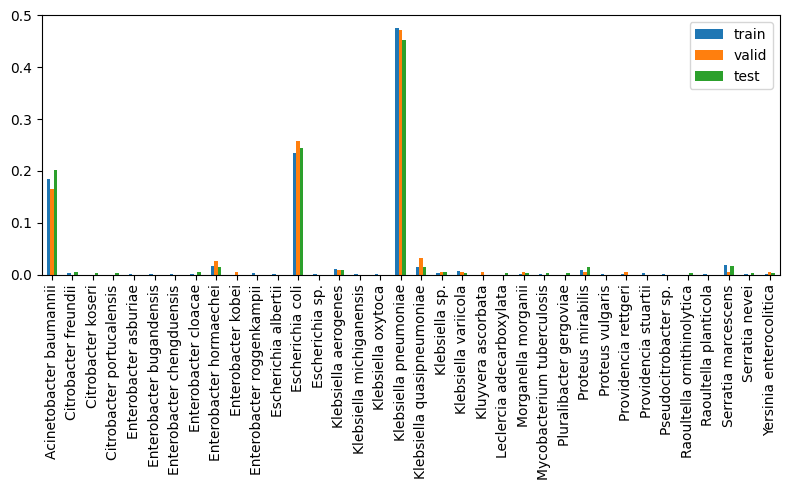

In [12]:
import matplotlib.pyplot as plt

distrib = pd.DataFrame({
    "train": metadata_cols.loc[df_train.index, "Species"].value_counts(normalize=True),
    "valid": metadata_cols.loc[df_valid.index, "Species"].value_counts(normalize=True),
    "test": metadata_cols.loc[df_test.index, "Species"].value_counts(normalize=True),
})

distrib.plot(kind="bar", figsize=(8, 5))
plt.tight_layout()
plt.show()

## Salvando

In [13]:
df_estruturada = RAIZ / "data/processed/df_estruturada"
df_estruturada.mkdir(parents=True, exist_ok=True)

df_train.to_csv(df_estruturada / "df_train.csv")
df_test.to_csv(df_estruturada / "df_test.csv")
df_valid.to_csv(df_estruturada / "df_valid.csv")